# 1. General Information

In this Notebook, we will explore and analyze data related to Life Expectancy across different countries and years. The primary focus will be on understanding the factors that influence life expectancy using factors that are in the data. We will start by visualizing the data to identify trends and patterns. Following this, we will apply statistical and machine learning models to predict life expectancy based on various indicators.

The goals of this notebook are:

* Data Exploration and Visualization: To examine the dataset, understand its structure, and identify any significant correlations or trends.
* Data Preprocessing: To clean and prepare the data for modeling, addressing any missing values or inconsistencies.
* Modeling Life Expectancy: To build predictive models that estimate life expectancy based on the provided features.
* Evaluation and Interpretation: To assess the performance of the models and interpret the results, drawing meaningful insights that can help inform public health strategies and policies.

By the end of this analysis, I hope to gain a deeper understanding of the key determinants of life expectancy and how these factors vary across different regions and periods.

# 2. Information about the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
data = pd.read_csv('Life Expectancy Data.csv.xls')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

As we see we have some null values in several features. Also we can see, that several columns have unnecessary spaces in their names. Antoher factor is that the names of the columns are not normalized - we will use snake case.

In [49]:
def snake_case(df_index: pd.Index) -> pd.Index:
    """
    Converts the column or index names from a Pandas DataFrame to snake_case format.

    This function replaces spaces in the names with underscores ("_") 
    and converts all characters to lowercase, following the snake_case naming convention.

    :param df_index: 
        The Pandas Index object, typically from `data.columns` or `data.index`, 
        representing the names to be transformed.
    :return: 
        A Pandas Index object with names converted to snake_case.
    """
    return df_index.str.strip().str.lower().str.replace(r'\s{1,2}', '_', regex=True)


In [53]:
data.columns = snake_case(data.columns)
data.head(2)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0


# 3. Splitting the data

In this part, we will simply split the data in train / validation / test dataset. However, first, we will try to find a good feature to stratify the data. After this step, we will no longer look at the test set. Stratifying the data is important beacuse using simple `train_test_split` can give us non population like results. For instance we can have a lot of countries that are developed and just few countries that are still developing which can result in a highly biased model.

## 3.1 Checking the Status Variable

Lets check if `status` variable is good for statifying the data, by visualing it.

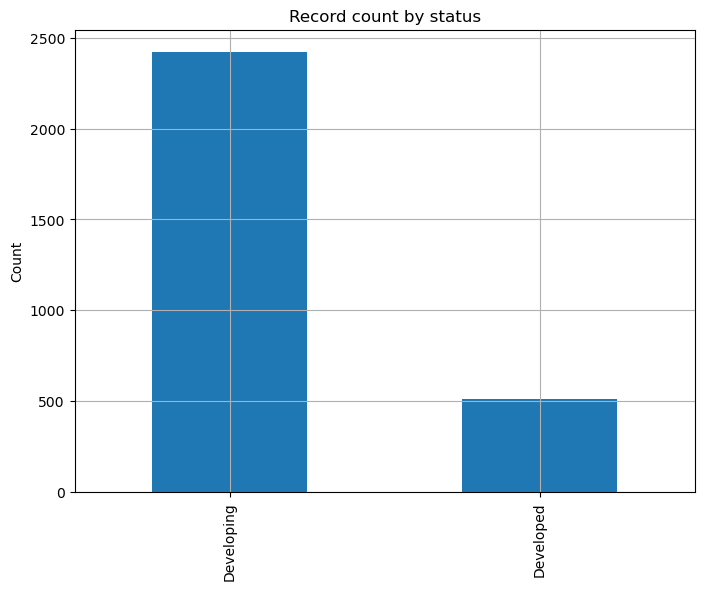

In [68]:
plt.figure(figsize=(8,6))
counts = data["status"].value_counts()
counts.plot(kind="bar");
plt.xlabel('');
plt.ylabel("Count");
plt.title("Record count by status");
plt.grid()

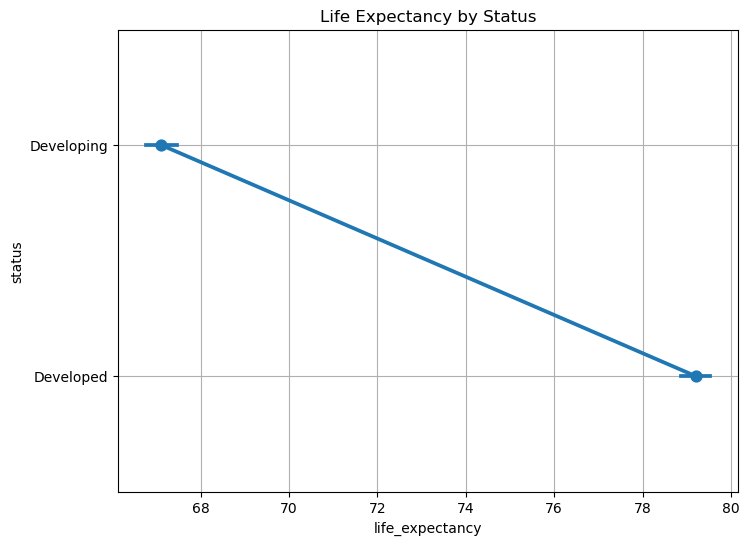

In [71]:
plt.figure(figsize=(8,6))
sns.pointplot(data, y="status", x="life_expectancy");
plt.title("Life Expectancy by Status");
plt.grid()

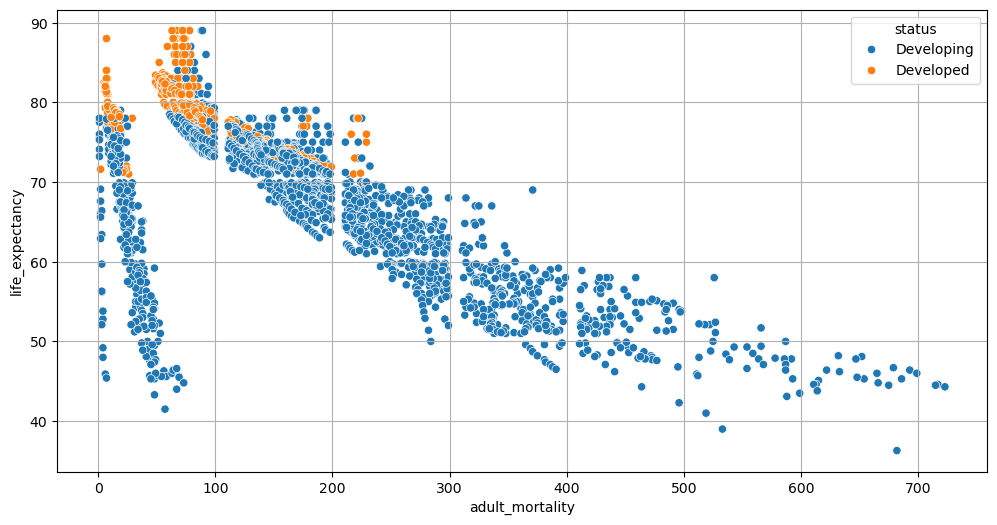

In [93]:
plt.figure(figsize=(12,6))
sns.scatterplot(data, x="adult_mortality",y="life_expectancy", hue="status")
plt.grid()

In [96]:
from scipy.stats import f_oneway
developing = data[data['status']=="Developing"]["life_expectancy"]
developed = data[data['status']=="Developed"]["life_expectancy"]
f_oneway(developed, developing, nan_policy = 'omit')

F_onewayResult(statistic=886.1555582795149, pvalue=2.4650861700059935e-170)

Visualisation and Anova test shown us, that there's a big difference between counties that are developing and those caounties that are developed - which can be a good thing to stratify the data.

## 3.2 Checking the Country Variable

Based on the plot that is shown above we can see that Countries differs from one another. The biggest issue by stratifying the data by `status` is that, the model will not be trained for each country, beacause sample data will not take countries into consideration. For experimentation purposes we will create two datasets:

* One will be stratified by status
* One will be stratified by counties (that appear more than five times in the dataset)

For each of those datasets we will perform the same calculations, however for purpose of this notebook we will focus on analysing the data that will be stratified by `status`.

In [125]:
from sklearn.model_selection import train_test_split

countries = data["country"].value_counts()[data["country"].value_counts() > 5].index
data_country_split = data[data['country'].isin(countries)]

# Splitting by Country
train_data_country, temp_data_country = train_test_split(
    data_country_split,
    train_size=0.7,
    stratify=data_country_split['country']
)

val_data_country, test_data_country = train_test_split(
    temp_data_country,
    train_size=0.5, #50% per each sample
    stratify=temp_data_country['country']
)


# Splitting by Status

train_data_status, temp_data_status = train_test_split(
    data,
    train_size=0.7,
    stratify=data['status']
)

val_data_status, test_data_status = train_test_split(
    temp_data_status,
    train_size=0.5,
    stratify=temp_data_status['status']
)

In [127]:
data['status'].value_counts() / len(data) * 100

status
Developing    82.573179
Developed     17.426821
Name: count, dtype: float64

In [129]:
train_data_status['status'].value_counts() / len(train_data_status) * 100

status
Developing    82.587549
Developed     17.412451
Name: count, dtype: float64

In [131]:
val_data_status['status'].value_counts() / len(val_data_status) * 100

status
Developing    82.539683
Developed     17.460317
Name: count, dtype: float64

In [132]:
test_data_status['status'].value_counts() / len(test_data_status) * 100

status
Developing    82.539683
Developed     17.460317
Name: count, dtype: float64

# 4. Exploratory Data Analysis

In this part:

* Check the quality of the data,

* Clean the data,

* Search for valuable correlation between the features,

* Prepare the data for modelling by building dedicated pipelines.


## 4.1 Data Cleansing

Ase we know from the second chapter, we have some features with missing data. In this subchapter we will try to do someting about it to increase the quality of the data.